# Task 4: Netflix Titles Dataset EDA and Insights

Objective: explore Netflix media content data and identify content type, country, genre, and year-wise trends.

## 1. Data Understanding and Cleaning

Place `netflix_titles.csv` in `../data/raw/` before running this notebook.

In [21]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT / 'src'))

from netflix_project import load_netflix_data, clean_and_engineer_netflix, explode_multilabel, save_netflix_visuals, netflix_insights

sns.set_theme(style='whitegrid')

In [11]:
df = pd.read_csv('E:\\Pythoon for DataSCIENCES\\Task3_Task4_Data_EDA_Project\\netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [12]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [13]:
df.isna().sum().sort_values(ascending=False).head(10)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
dtype: int64

## 2. Feature Engineering

The helper function parses `date_added`, fills missing text columns, creates `release_decade`, `content_type`, `is_movie`, `year_added`, and `month_added`.

In [14]:
cleaned = clean_and_engineer_netflix(df)
cleaned.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,release_decade,content_type,is_movie,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2020s,Movie,1,2021.0,9.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2020s,TV Show,0,2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2020s,TV Show,0,2021.0,9.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2020s,TV Show,0,2021.0,9.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2020s,TV Show,0,2021.0,9.0


In [15]:
top_5_countries = explode_multilabel(cleaned, 'country')
top_5_countries = top_5_countries[top_5_countries != 'Unknown'].value_counts().head(5)
top_5_countries

country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Name: count, dtype: int64

## 3. Visualization and Insights

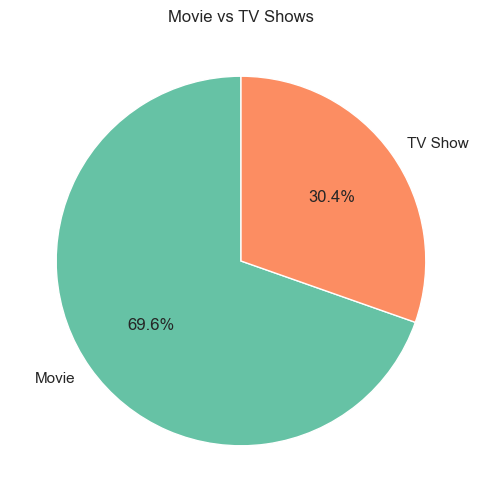

In [16]:
type_counts = cleaned['type'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2'))
plt.title('Movie vs TV Shows')
plt.show()

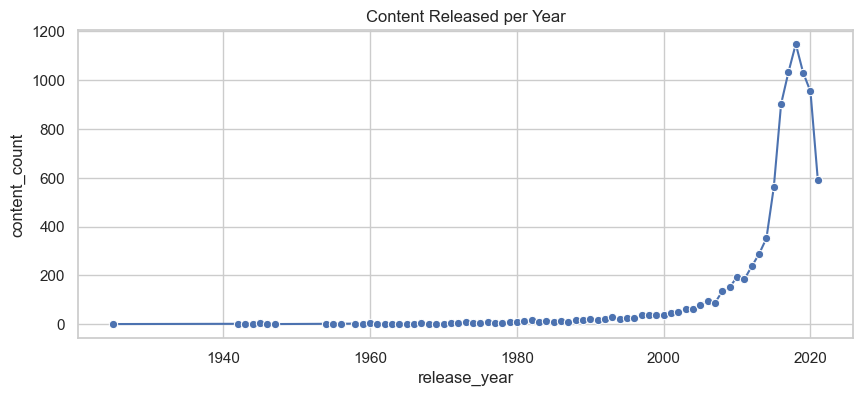

In [17]:
yearly = cleaned.dropna(subset=['release_year']).groupby('release_year').size().reset_index(name='content_count')
plt.figure(figsize=(10, 4))
sns.lineplot(data=yearly, x='release_year', y='content_count', marker='o')
plt.title('Content Released per Year')
plt.show()

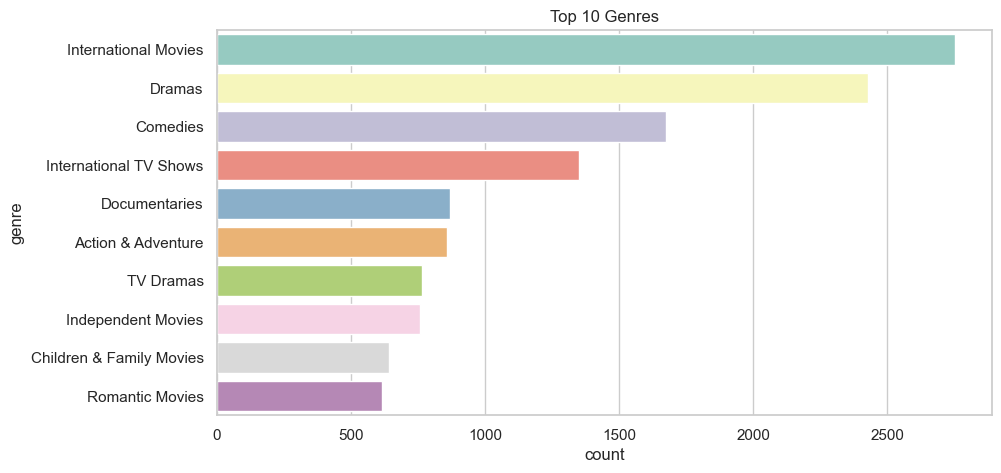

In [18]:
genres = explode_multilabel(cleaned, 'listed_in').value_counts().head(10).reset_index()
genres.columns = ['genre', 'count']
plt.figure(figsize=(10, 5))
sns.barplot(data=genres, x='count', y='genre', hue='genre', palette='Set3', legend=False)
plt.title('Top 10 Genres')
plt.show()

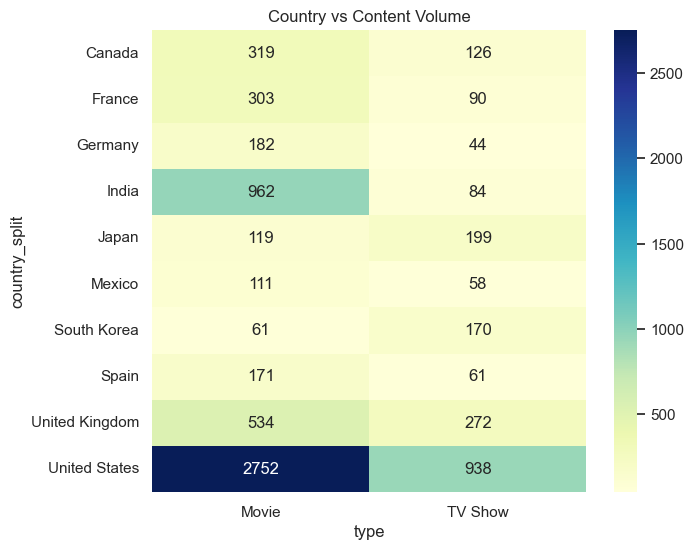

In [19]:
country_rows = cleaned.assign(country_split=cleaned['country'].str.split(',')).explode('country_split')
country_rows['country_split'] = country_rows['country_split'].str.strip()
top_countries = country_rows[country_rows['country_split'] != 'Unknown']['country_split'].value_counts().head(10).index
heatmap_data = country_rows[country_rows['country_split'].isin(top_countries)].pivot_table(
    index='country_split', columns='type', values='show_id', aggfunc='count', fill_value=0
)
plt.figure(figsize=(7, 6))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Country vs Content Volume')
plt.show()

## 4. Save Deliverables

In [20]:
processed_dir = PROJECT_ROOT / 'data' / 'processed'
figures_dir = PROJECT_ROOT / 'reports' / 'figures'
processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

cleaned.to_csv(processed_dir / 'netflix_titles_cleaned.csv', index=False)
save_netflix_visuals(cleaned, figures_dir)

for i, insight in enumerate(netflix_insights(cleaned), start=1):
    print(f'{i}. {insight}')

1. Movie titles dominate the catalog with 6131 records.
2. United States is the most frequent production country, showing strong catalog representation.
3. International Movies is the most common listed genre/category.
4. The busiest release year in the dataset is 2018.
5. Simple trend prediction estimates about 1901 additions in 2022 and 1986 in 2023.
6. What this means: Netflix catalog decisions can be guided by country, genre, and release-year patterns.
